# Multigrid Track — Phase 0–2a Validation Notebook

Reproduces every test of `multigrid_selfgravity_validation.pdf`: the shearing-box +
mesh-refinement infrastructure (orbital-advection toggle, uniform-boundary-level and annular
refinement policies, FARGO on refined meshes), and the Phase-1 shear-periodic multigrid
boundary conditions validated against the FFT oracle.

**Prerequisites**: the code built (`cmake .. && make -j8`; section 9's oracle runs need
`-D Athena_ENABLE_FFT=ON`) and Julia packages `CairoMakie`, `IJulia`.

**Structure**
1. Helpers: running AthenaK, reading `.hst` and per-block `.bin`
2. Frame consistency: FARGO vs full-velocity (uniform grid)
3. Guard checks: the two policies must refuse illegal setups
4. FARGO on an annular refined ring vs its non-FARGO twin
5. The 20-orbit epicycle endurance test (the decisive one)
6. Two-level refinement (levels 1 and 2)
7. Mesh-layout visualization from `.bin` outputs
8. AMR: dynamic ring creation/destruction (Phase 0c) and its convergence
9. Phase 1: shear-periodic multigrid boundary conditions vs the FFT oracle
10. Tomida & Stone (2023) §4.1: sinusoidal-wave static test vs the published results
11. Tomida & Stone (2023) §4.3: Jeans-wave dynamical test
12. Phase 2a: multigrid gravity on refined meshes (interior rings)
13. Playground


In [79]:
const REPO   = expanduser("~/Library/CloudStorage/Dropbox/Research/code/athenak-multigrid")
const ATHENA = joinpath(REPO, "build", "src", "athena")
const INPUTS = joinpath(REPO, "inputs")
const RUN    = joinpath(REPO, "validation", "run")          # short shwave/ring tests
const RUNEPI = joinpath(REPO, "validation", "run_epicycle") # 20-orbit epicycle runs
mkpath(RUN); mkpath(RUNEPI)
isfile(ATHENA) || @warn "athena executable not found -- build first"
using CairoMakie, Printf
CairoMakie.activate!(type="png")
set_theme!(Theme(fontsize=13, Axis=(xgridcolor=(:gray, 0.25), ygridcolor=(:gray, 0.25))))
const C1, C2, C3, C4 = "#2a78d6", "#eb6834", "#1baf7a", "#eda100";


In [80]:
"Run athena on `input` (path relative to inputs/) in `dir` with overrides; return stdout."
function run_athena(input; overrides=String[], dir=RUN)
    cmd = Cmd(String[ATHENA, "-i", joinpath(INPUTS, input), overrides...])
    read(pipeline(Cmd(cmd; dir=dir); stderr=devnull), String)
end

"Run athena expecting a FATAL abort; return the fatal message lines."
function run_expect_fatal(input; overrides=String[], dir=RUN)
    out = read(pipeline(ignorestatus(Cmd(Cmd(String[ATHENA, "-i",
              joinpath(INPUTS, input), overrides...]); dir=dir)); stderr=devnull), String)
    lines = split(out, '\n')
    i = findfirst(l -> occursin("FATAL", l), lines)
    i === nothing ? error("expected a FATAL error but the run proceeded!") :
                    join(lines[i:min(i+3, length(lines))], '\n')
end

"Read an AthenaK .hst file into a matrix (rows = outputs)."
function read_hst(f)
    rows = Float64[]; ncol = 0
    for ln in eachline(f)
        startswith(strip(ln), "#") && continue
        v = parse.(Float64, split(ln)); ncol = length(v); append!(rows, v)
    end
    permutedims(reshape(rows, ncol, :))
end

"Read an AthenaK .bin file into per-MeshBlock records (multilevel-safe)."
function read_bin_blocks(filename)
    open(filename, "r") do io
        startswith(readline(io), "Athena binary output") || error("not an AthenaK bin")
        npre = parse(Int, split(readline(io), "=")[end])
        ph = Dict(String(strip(k)) => String(strip(v)) for (k, v) in
                  (split(readline(io), "=") for _ in 1:npre-1))
        locsize = parse(Int, ph["size of location"])
        varsize = parse(Int, ph["size of variable"])
        nvars = parse(Int, split(readline(io), "=")[end])
        vars = String.(split(readline(io))[2:end])
        hsize = parse(Int, split(readline(io), "=")[end])
        header = String(read(io, hsize))
        m = match(r"nghost\s*=\s*(\d+)", header)
        ng = parse(Int, m.captures[1])
        locT = locsize == 8 ? Float64 : Float32
        varT = varsize == 8 ? Float64 : Float32
        blocks = NamedTuple[]
        while !eof(io)
            idx = Int.(reinterpret(Int32, read(io, 24))) .- ng
            n1 = idx[2]-idx[1]+1; n2 = idx[4]-idx[3]+1; n3 = idx[6]-idx[5]+1
            logical = Int.(reinterpret(Int32, read(io, 16)))       # lx1,lx2,lx3,level
            geom = Float64.(reinterpret(locT, read(io, 6*locsize)))  # x1min..x3max
            raw = reinterpret(varT, read(io, n1*n2*n3*nvars*varsize))
            data = reshape(Float64.(raw), (n1, n2, n3, nvars))
            push!(blocks, (logical=logical, geom=geom, data=data))
        end
        (blocks=blocks, vars=vars)
    end
end;


## 1. Frame consistency — FARGO vs full-velocity, uniform grid

`<shearing_box> orbital_advection = false` switches to the full-velocity frame: the
solver integrates the shear directly, with full Coriolis + tidal source terms and
momentum/energy offsets in the shear-periodic wrap. Same physics, different variables —
frame-independent diagnostics must agree to truncation order.

In [ ]:
for (bn, ov) in (("shw_fargo", String[]),
                 ("shw_nofargo", ["shearing_box/orbital_advection=false"]))
    isfile(joinpath(RUN, bn * ".hydro.hst")) ||
        run_athena("shearing_box/hydro_incompress_shwave.athinput";
                   overrides=vcat("job/basename=$bn", ov))
end
a = read_hst(joinpath(RUN, "shw_fargo.hydro.hst"))
b = read_hst(joinpath(RUN, "shw_nofargo.hydro.hst"))
n = min(size(a, 1), size(b, 1))
@printf("mass : max rel diff = %.2e   (frame-independent, expect ~0)\n",
        maximum(abs.(a[1:n,3] .- b[1:n,3]))/maximum(abs.(a[1:n,3])))
@printf("x-KE : max rel diff = %.4f   (truncation gap between the two schemes)\n",
        maximum(abs.(a[1:n,7] .- b[1:n,7]))/maximum(abs.(a[1:n,7])))


## 2. Guard checks — the policies must refuse illegal setups

The policies are enforced with fatal errors, not conventions. Three runs that must
abort: a refined region that puts *mixed* levels on the shear-periodic $x_1$ boundary,
refining only *one* boundary face (mixed levels across the wrap), and a partial-$x_2$
ring with FARGO on.

In [ ]:
println("--- uniform-boundary-level policy (partial boundary refinement):")
println(run_expect_fatal("shearing_box/hydro_incompress_shwave_smr.athinput";
        overrides=["refined_region1/x1min=-0.24", "refined_region1/x1max=-0.13"]))
println("\n--- uniform-boundary-level policy (only ONE face refined):")
println(run_expect_fatal("shearing_box/hydro_incompress_shwave_smr_bndry.athinput";
        overrides=["refined_region2/x1min=0.0", "refined_region2/x1max=0.12"]))
println("\n--- annular policy (partial ring + FARGO):")
println(run_expect_fatal("shearing_box/hydro_incompress_shwave_smr.athinput";
        overrides=["shearing_box/orbital_advection=true"]))


## 3. FARGO on an annular refined ring

The `_ring` input refines a full-$x_2$ level-1 annulus (interior in $x_1$). Every
$x_2$-face neighbor is then same-level, so the per-block shift kernel and the existing
communication run unchanged, level by level. Checks: exact mass conservation, and
agreement with the non-FARGO twin at the same truncation level as on uniform grids.

In [ ]:
for (bn, ov) in (("ring_fargo", String[]),
                 ("ring_nofargo", ["shearing_box/orbital_advection=false"]))
    isfile(joinpath(RUN, bn * ".hydro.hst")) ||
        run_athena("shearing_box/hydro_incompress_shwave_smr_ring.athinput";
                   overrides=vcat("job/basename=$bn", ov))
end
rf = read_hst(joinpath(RUN, "ring_fargo.hydro.hst"))
rn = read_hst(joinpath(RUN, "ring_nofargo.hydro.hst"))
n = min(size(rf, 1), size(rn, 1))
@printf("ring+FARGO mass drift        = %.2e   (expect exactly 0)\n",
        maximum(abs.(rf[:,3] .- rf[1,3])))
@printf("ring FARGO vs non-FARGO x-KE = %.4f   (uniform-grid gap was 3.3%%)\n",
        maximum(abs.(rf[1:n,7] .- rn[1:n,7]))/maximum(abs.(rf[1:n,7])))


## 4. Refined $x_1$ boundary faces

The uniform-boundary-level rule permits refinement *at* the shear boundary when
**both** faces are refined uniformly (full $x_2$/$x_3$, same level) — natural for a
structure at the boundary, whose shear-periodic images live on both faces. The
`_bndry` input refines the leftmost and rightmost root columns to level 1. The
decisive check is again the spatially uniform epicycle: it must pass through the
level-1 shear-periodic wrap and the level-1 azimuthal redistribution exactly.

In [ ]:
for (bn, ov) in (("shwave2_smr_bndry", String[]),
                 ("epi_bndry", ["problem/ipert=1"]))
    isfile(joinpath(RUN, bn * ".hydro.hst")) ||
        run_athena("shearing_box/hydro_incompress_shwave_smr_bndry.athinput";
                   overrides=vcat("job/basename=$bn", ov))
end
eb = read_hst(joinpath(RUN, "epi_bndry.hydro.hst"))
t = eb[:, 1]; amp = 1.0e-4; V = 0.125
ana = 0.5*V*amp^2 .* cos.(t).^2
@printf("epicycle, boundary annuli + FARGO vs analytic: max rel = %.3e\n",
        maximum(abs.(eb[:,7] .- ana))/maximum(ana))
sb = read_hst(joinpath(RUN, "shwave2_smr_bndry.hydro.hst"))
su = read_hst(joinpath(RUN, "shw_fargo.hydro.hst"))     # uniform reference (Sec. 1)
n = min(size(sb, 1), size(su, 1))
@printf("shwave, boundary annuli: mass drift = %.2e,  x-KE vs uniform = %.4f\n",
        maximum(abs.(sb[:,3] .- sb[1,3])),
        maximum(abs.(sb[1:n,7] .- su[1:n,7]))/maximum(abs.(su[1:n,7])))


## 5. The endurance test — epicycles for 20 orbits

`ipert=1` initializes a spatially **uniform** epicycle $v_x(0)=A$, an exact nonlinear
solution: $v_x = A\cos\kappa t$, $v_y' = -(A\kappa/2\Omega)\sin\kappa t$, with
$\kappa=\Omega$ at $q=3/2$. A uniform field must pass through the $y$-shift *exactly*,
so any indexing/communication defect at ring or level boundaries appears as $O(1)$
corruption — while phase/amplitude errors of the time integrator stay tiny and smooth.
The **amplitude invariant** $A(t)=\sqrt{v_x^2+(2\Omega/\kappa)^2v_y'^2}$ separates
numerical damping (drift in $A$) from phase error.

Note on units: `amp = 0.1` is a velocity in code units (`shwave.cpp` never multiplies
by $c_s$); with the ideal EOS at $p_0=\rho_0=1$, $c_s=\sqrt{5/3}$, so this epicycle is
$0.077\,c_s$ — the plot is normalized to `amp`, oscillating between $\pm1$.

In [ ]:
# ~1 min (uniform) + ~3 min each (ring, bndry) if the runs don't exist yet
isfile(joinpath(RUNEPI, "epi_unif.hydro.hst")) ||
    run_athena("shearing_box/epicycle.athinput"; dir=RUNEPI)
isfile(joinpath(RUNEPI, "epi_ring.hydro.hst")) ||
    run_athena("shearing_box/epicycle_smr_ring.athinput"; dir=RUNEPI)
isfile(joinpath(RUNEPI, "epi_bndry.hydro.hst")) ||
    run_athena("shearing_box/epicycle_smr_bndry.athinput"; dir=RUNEPI)

amp, Ω, q = 0.1, 1.0, 1.5
κ = sqrt(2*(2-q))*Ω
Torb = 2π/Ω
u = read_hst(joinpath(RUNEPI, "epi_unif.hydro.hst"))
r = read_hst(joinpath(RUNEPI, "epi_ring.hydro.hst"))
bd = read_hst(joinpath(RUNEPI, "epi_bndry.hydro.hst"))
vx_u = u[:,4]./u[:,3]; vy_u = u[:,5]./u[:,3]; t_u = u[:,1]
vx_r = r[:,4]./r[:,3]; vy_r = r[:,5]./r[:,3]; t_r = r[:,1]
vx_b = bd[:,4]./bd[:,3]; vy_b = bd[:,5]./bd[:,3]; t_b = bd[:,1]
envel(vx, vy) = sqrt.(vx.^2 .+ (2Ω/κ)^2 .* vy.^2)
A_u, A_r, A_b = envel(vx_u, vy_u), envel(vx_r, vy_r), envel(vx_b, vy_b)
epi_ana(t) = amp .* cos.(κ .* t)
for (tag, t, v, A) in (("uniform    ", t_u, vx_u, A_u), ("ring+FARGO ", t_r, vx_r, A_r),
                       ("bndry+FARGO", t_b, vx_b, A_b))
    @printf("%s  vx∈[%+.5f, %+.5f]  amplitude drift %+.3f%%  max|vx-analytic|/amp = %.4f\n",
            tag, minimum(v), maximum(v), 100*(A[end]-A[1])/amp,
            maximum(abs.(v .- epi_ana(t)))/amp)
end
n = min(size(r,1), size(bd,1))
@printf("\nboundary-annuli vs interior-ring endurance run, all columns: max diff = %.1e\n",
        maximum(abs.(r[1:n,:] .- bd[1:n,:])))


In [ ]:
fig = Figure(size=(880, 620))
ax1 = Axis(fig[1,1]; xlabel="t / T_orb", ylabel="vₓ / amp",
           title="Epicyclic radial velocity over 20 orbits")
hlines!(ax1, [-1, 1]; color=(:gray, 0.55), linestyle=:dash)
lines!(ax1, t_u ./ Torb, vx_u ./ amp; color=C1, linewidth=1.2, label="uniform grid")
lines!(ax1, t_r ./ Torb, vx_r ./ amp; color=C3, linewidth=1.2, linestyle=:dash,
       label="annular ring + FARGO")
lines!(ax1, t_b ./ Torb, vx_b ./ amp; color=C4, linewidth=1.2, linestyle=:dot,
       label="boundary annuli + FARGO")
axislegend(ax1; position=:rt, framevisible=false, orientation=:horizontal)
ylims!(ax1, -1.35, 1.35)

sel_u = t_u ./ Torb .>= 18; sel_r = t_r ./ Torb .>= 18
tf = range(18Torb, t_u[end]; length=600)
ax2 = Axis(fig[2,1]; xlabel="t / T_orb", ylabel="vₓ / amp", height=150,
           title="last two orbits vs analytic amp·cos(κt)")
lines!(ax2, tf ./ Torb, epi_ana(tf) ./ amp; color=C2, linewidth=2.5, label="analytic")
scatter!(ax2, t_u[sel_u] ./ Torb, vx_u[sel_u] ./ amp; color=C1, markersize=6,
         label="uniform")
scatter!(ax2, t_r[sel_r] ./ Torb, vx_r[sel_r] ./ amp; color=C3, marker=:rect,
         markersize=5, label="ring")
sel_b = t_b ./ Torb .>= 18
scatter!(ax2, t_b[sel_b] ./ Torb, vx_b[sel_b] ./ amp; color=C4, marker=:diamond,
         markersize=5, label="bndry")
axislegend(ax2; position=:rt, framevisible=false, orientation=:horizontal)

ax3 = Axis(fig[3,1]; xlabel="t / T_orb", ylabel="A(t) / amp", height=150,
           title="amplitude invariant — flat means no numerical damping")
hlines!(ax3, [1.0]; color=(:gray, 0.55), linestyle=:dash)
lines!(ax3, t_u ./ Torb, A_u ./ amp; color=C1, linewidth=1.5, label="uniform")
lines!(ax3, t_r ./ Torb, A_r ./ amp; color=C3, linewidth=1.5, linestyle=:dash,
       label="ring + FARGO")
lines!(ax3, t_b ./ Torb, A_b ./ amp; color=C4, linewidth=1.5, linestyle=:dot,
       label="bndry + FARGO")
axislegend(ax3; position=:rb, framevisible=false, orientation=:horizontal)
fig


## 6. Two-level refinement (levels 1 and 2)

Both policies recurse in level, so deeper hierarchies need no new machinery — verified
with two configurations at levels 1+2 (8 root + 32 level-1 + 256 level-2 blocks each,
FARGO on): nested interior rings, and level-2 boundary annuli with level-1 buffer rings
inboard (2:1 nesting). The epicycle is again the decisive check.

In [ ]:
for (inp, bn) in (("hydro_incompress_shwave_smr_ring2.athinput", "epi_ring2"),
                  ("hydro_incompress_shwave_smr_bndry2.athinput", "epi_bndry2"))
    isfile(joinpath(RUN, bn * ".hydro.hst")) ||
        run_athena("shearing_box/" * inp;
                   overrides=["job/basename=$bn", "problem/ipert=1"])
end
e2r = read_hst(joinpath(RUN, "epi_ring2.hydro.hst"))
e2b = read_hst(joinpath(RUN, "epi_bndry2.hydro.hst"))
t2 = e2r[:,1]; amp2 = 1.0e-4; V = 0.125
ana2 = 0.5*V*amp2^2 .* cos.(t2).^2
@printf("epicycle, nested rings (L1+L2)      vs analytic: max rel = %.3e\n",
        maximum(abs.(e2r[:,7] .- ana2))/maximum(ana2))
@printf("epicycle, two-level boundary annuli vs analytic: max rel = %.3e\n",
        maximum(abs.(e2b[:,7] .- ana2))/maximum(ana2))
n = min(size(e2r,1), size(e2b,1))
@printf("the two two-level meshes vs each other, all columns: max diff = %.1e\n",
        maximum(abs.(e2r[1:n,:] .- e2b[1:n,:])))


## 7. Mesh-layout visualization

Drawn directly from the per-block structure of the `.bin` outputs — the same reader you
will use for any refined-mesh analysis. Left: the interior patch (legal only without
FARGO). Right: the annular ring (FARGO-legal). Orange lines mark the shear-periodic
$x_1$ boundaries that refinement must avoid.

In [ ]:
function draw_blocks!(ax, fd; title="")
    lev_col = Dict(0 => :white, 1 => "#dbe9fb", 2 => "#b9d5f6")
    z0 = minimum(b.geom[5] for b in fd.blocks)
    for b in fd.blocks
        b.geom[5] ≈ z0 || continue          # one z-layer
        g = b.geom; lev = b.logical[4]
        poly!(ax, Rect2(g[1], g[3], g[2]-g[1], g[4]-g[3]);
              color=get(lev_col, lev, "#8fbdf0"), strokecolor=:black, strokewidth=0.8)
    end
    ax.title = title
end

# the patch (partial-x2) run is legal only with FARGO off; generate it if absent
isfile(joinpath(RUN, "shwave2_nofargo_smr.hydro.hst")) ||
    run_athena("shearing_box/hydro_incompress_shwave_smr.athinput";
               overrides=["shearing_box/orbital_advection=false",
                          "job/basename=shwave2_nofargo_smr"])
f_patch = first(sort(filter(f -> occursin("shwave2_nofargo_smr.hydro_w", f),
                            readdir(joinpath(RUN, "bin"); join=true))))
f_ring = first(sort(filter(f -> occursin("ring_fargo.hydro_w", f),
                           readdir(joinpath(RUN, "bin"); join=true))))
fig = Figure(size=(860, 430))
for (i, (f, ttl)) in enumerate(((f_patch, "patch (FARGO off only)"),
                                (f_ring, "annular ring (FARGO OK)")))
    ax = Axis(fig[1, i]; xlabel="x", ylabel=(i == 1 ? "y" : ""), aspect=DataAspect())
    draw_blocks!(ax, read_bin_blocks(f); title=ttl)
    vlines!(ax, [-0.25, 0.25]; color=C2, linewidth=3)
end
fig


## 8. AMR — dynamic ring creation and destruction (Phase 0c)

AMR renumbers MeshBlock GIDs on every update, so the shear-boundary communication
state (GID lists, MPI requests, buffers) built at construction goes stale.
`ShearingBox::ReinitAfterMeshUpdate` (commit `b5388c02`) rebuilds it after every
mesh update; a **graded cap** in `CheckForRefinement` refuses refinement whose 2:1
balancing would reach the shear-periodic boundary columns
($2^{s+1}-1 \le l_{x1} \le n_{x1}-2^{s+1}$ at $s$ levels above the boundary
level); and an upstream derefinement-sort bug (end iterator excluded the last
element → order-dependent partial ring merges, commit `f0acd383`) is fixed.

The dynamic exercise is a **prescribed moving ring** (`MovingRingRefine` in the
shwave pgen): refine blocks overlapping $[x_c(t)-w, x_c(t)+w]$ with
$x_c = A\sin(ft)$, derefine everything else. With $A$ past the vetoed boundary
columns, all rings are destroyed near each turning point and re-created on the way
back. The 20-orbit epicycle run creates 2296 / destroys 2240 MeshBlocks with
exactly zero mass drift, bit-reproducible across reruns.

In [ ]:
# ~4 min (20-orbit AMR) + ~2 min (two-level) + ~2 min (non-FARGO) if absent
for (hst, inp, log) in (("epi_amr.hydro.hst", "epicycle_amr_ring.athinput", "log_amr.txt"),
                        ("epi_amr2.hydro.hst", "epicycle_amr_ring2.athinput", "log_amr2.txt"),
                        ("epi_amr_nofargo.hydro.hst", "epicycle_amr_ring_nofargo.athinput",
                         "log_amr_nofargo.txt"))
    if !isfile(joinpath(RUNEPI, hst))
        out = run_athena("shearing_box/" * inp; dir=RUNEPI)
        write(joinpath(RUNEPI, log), out)
    end
end
for log in ("log_amr.txt", "log_amr2.txt", "log_amr_nofargo.txt")
    f = joinpath(RUNEPI, log)
    isfile(f) && for ln in eachline(f)
        occursin("created", ln) && @printf("%-18s %s\n", log, ln)
    end
end

# amplitude drift and time-matched x-KE difference vs the section-5 references
amp, Ω, q = 0.1, 1.0, 1.5
κ = sqrt(2*(2-q))*Ω
u = read_hst(joinpath(RUNEPI, "epi_unif.hydro.hst"))
r = read_hst(joinpath(RUNEPI, "epi_ring.hydro.hst"))
a = read_hst(joinpath(RUNEPI, "epi_amr.hydro.hst"))
envel(h) = sqrt.((h[:,4]./h[:,3]).^2 .+ (2Ω/κ)^2 .* (h[:,5]./h[:,3]).^2)
for (tag, h) in (("uniform ", u), ("ring    ", r), ("amr     ", a))
    A = envel(h)
    @printf("%s mass drift %.1e   amplitude drift %+.3e\n", tag,
            maximum(abs.(h[:,3] .- h[1,3]))/h[1,3], (A[end]-A[1])/amp)
end
# linear-interp time-matched max |Δ(1-KE)| (col 8, ideal EOS), scaled to the peak
function tmdiff(p, b; col=8)
    mx = 0.0
    for i in 1:size(p,1)
        t = p[i,1]; j = searchsortedlast(b[:,1], t)
        (j < 1 || j >= size(b,1)) && continue
        w = (t - b[j,1])/(b[j+1,1] - b[j,1])
        mx = max(mx, abs(p[i,col] - ((1-w)*b[j,col] + w*b[j+1,col])))
    end
    mx / maximum(b[:,col])
end
@printf("\ntime-matched x-KE:  amr vs ring %.2e   amr vs uniform %.2e   ring vs uniform %.2e\n",
        tmdiff(a, r), tmdiff(a, u), tmdiff(r, u))

In [ ]:
# MeshBlock-count history from the bin outputs, with the prescribed ring center
files = sort(filter(f -> startswith(f, "epi_amr.hydro_w."),
                    readdir(joinpath(RUNEPI, "bin"))))
nmb = [length(read_bin_blocks(joinpath(RUNEPI, "bin", f)).blocks) for f in files]
tt = 0.628 .* (0:length(nmb)-1)   # output cadence dt = 0.628 (see the input file)
Torb = 2π
fig = Figure(size=(880, 300))
ax = Axis(fig[1,1]; xlabel="t / T_orb", ylabel="MeshBlocks",
          title="moving-ring AMR: block count (blue) and ring center (orange)")
stairs!(ax, collect(tt) ./ Torb, nmb; color=C1, step=:post)
axr = Axis(fig[1,1]; yaxisposition=:right, ylabel="x_c(t)", ylabelcolor=C2,
           yticklabelcolor=C2)
hidespines!(axr); hidexdecorations!(axr)
lines!(axr, collect(tt) ./ Torb, 7.0 .* sin.(tt); color=(C2, 0.55))
hlines!(axr, [-5, 5]; color=(:gray, 0.5), linestyle=:dash)
xlims!(ax, 0, 20); xlims!(axr, 0, 20)
@printf("blocks: min %d  max %d  (16 = all-root)\n", minimum(nmb), maximum(nmb))
fig

### 8.1 Wave structure through a moving refinement boundary

The epicycle is spatially uniform — it never exercises prolongation/restriction on
real structure. The vortical-shwave AMR test runs the JG05 problem of section 1
under a moving ring ($x_c = 0.2\sin t$, $w = 0.05$), so wave structure crosses
every regrid event. At $64^2$ the moving ring roughly doubles the static-ring
truncation (the ring covers only ~1.6 wavelengths and full destruction restricts
fine data mid-swing); at $128^2$ moving and static rings agree to $1.8\times10^{-4}$
— the regridding cost converges away with no floor.

In [ ]:
# ~2 min (64²) + ~15 min for the 128² trio if absent
isfile(joinpath(RUN, "shwave2_amr.hydro.hst")) || begin
    out = run_athena("shearing_box/hydro_incompress_shwave_amr_ring.athinput"; dir=RUN)
    write(joinpath(RUN, "log_shwave2_amr.txt"), out)
end
r128 = [("shw_fargo128", "hydro_incompress_shwave.athinput", String[]),
        ("ring_fargo128", "hydro_incompress_shwave_smr_ring.athinput", String[]),
        ("shwave2_amr128", "hydro_incompress_shwave_amr_ring.athinput",
         ["mesh_refinement/max_nmb_per_rank=384"])]
for (bn, inp, extra) in r128
    isfile(joinpath(RUN, bn * ".hydro.hst")) && continue
    out = run_athena("shearing_box/" * inp;
                     overrides=vcat(["mesh/nx1=128", "mesh/nx2=128",
                                     "job/basename=" * bn], extra), dir=RUN)
    write(joinpath(RUN, "log_" * bn * ".txt"), out)
end

# keep the last monotone-time segment (guards against appended reruns)
seg(h) = begin
    s = 1
    for i in 2:size(h,1); h[i,1] <= h[i-1,1] && (s = i); end
    h[s:end, :]
end
hst(f) = seg(read_hst(joinpath(RUN, f)))
for (res, fu, fr, fa) in (("64 ", "shw_fargo.hydro.hst", "ring_fargo.hydro.hst",
                           "shwave2_amr.hydro.hst"),
                          ("128", "shw_fargo128.hydro.hst", "ring_fargo128.hydro.hst",
                           "shwave2_amr128.hydro.hst"))
    hu, hr, ha = hst(fu), hst(fr), hst(fa)
    pu = maximum(hu[:,7])   # isothermal EOS: x-KE is column 7
    @printf("N=%s  peak x-KE err: ring %+.2f%%  amr %+.2f%%   amr-vs-ring %.1e   mass %.1e\n",
            res, 100*(maximum(hr[:,7])/pu - 1), 100*(maximum(ha[:,7])/pu - 1),
            tmdiff(ha, hr; col=7), maximum(abs.(ha[:,3] .- ha[1,3]))/ha[1,3])
end

In [ ]:
hu, hr, ha = hst("shw_fargo128.hydro.hst"), hst("ring_fargo128.hydro.hst"),
             hst("shwave2_amr128.hydro.hst")
fig = Figure(size=(700, 340))
ax = Axis(fig[1,1]; xlabel="t", ylabel="x-kinetic energy",
          title="128² vortical shwave through the swing (t_swing = 2.67)")
lines!(ax, hu[:,1], hu[:,7]; color=C1, linewidth=4, label="uniform")
lines!(ax, hr[:,1], hr[:,7]; color=C3, linewidth=2.2, label="static ring (SMR)")
lines!(ax, ha[:,1], ha[:,7]; color=C2, linewidth=1.2, linestyle=:dash,
       label="moving ring (AMR)")
axislegend(ax; position=:lt, framevisible=false)
fig

## 9. Phase 1 — shear-periodic multigrid boundary conditions

The multigrid Poisson solver with `shear_periodic` $x_1$ boundaries: a $y$-remapped ghost
fill applied at every MG level through global boundary planes (§9 of the PDF), with the FFT
solver as the oracle. Every run below reuses an FFT-track input with the single override
`gravity/solver=multigrid`. Tests: (i) solves at shear-periodic instants must be
**bit-identical** to plain-periodic solves; (ii) generic-phase residual (self-consistency
only — a converged-but-wrong identification would also drive it to zero); (iii) the analytic
shearing-wave potential — the sign arbiter, $O(1)$ under any sign/offset error; (iv) the
V-cycle contraction rate under remapped boundaries (the open risk named in Phase 0); (v) the
swing-amplification A/B with `solver=multigrid`.

Most cells run the serial binary; the final cell reruns the key checks with the
multi-rank seam (one `MPI_Allreduce` reconstructing the boundary planes from each
rank's local gather) and is skipped automatically unless an MPI build
(`build-mpi/`, `-D Athena_ENABLE_MPI=ON`) and `mpirun` are available.


In [ ]:
# ~30 s at first run: 64³ shear-instant tests + periodic reference (logs cached in run/)
mgsolve(bn; input="tests/fft_poisson_shear.athinput", ov=String[]) = begin
    log = joinpath(RUN, "log_" * bn * ".txt")
    isfile(log) || write(log, run_athena(input; overrides=vcat("job/basename=$bn", ov)))
    read(log, String)
end
grab(out, tag) = strip(split(split(out, tag; limit=2)[2], '\n')[1])
const MG = ["gravity/solver=multigrid"]

out_per = mgsolve("mgp_periodic"; input="tests/fft_poisson.athinput", ov=MG)
out_t0  = mgsolve("mgp_shear_t0";  ov=vcat(MG, "problem/time0=0.0"))
out_tsh = mgsolve("mgp_shear_tsh"; ov=vcat(MG, "problem/time0=0.6666666666666666"))

phibin(bn) = read_bin_blocks(joinpath(RUN, "bin", bn * ".grav_phi.00000.bin")) 
same(a, b) = all(ba.data == bb.data for (ba, bb) in zip(a.blocks, b.blocks))
p, t0, tsh = phibin("mgp_periodic"), phibin("mgp_shear_t0"), phibin("mgp_shear_tsh")
println("qomt = 0 instants vs plain-periodic multigrid solve (float32 bin data):")
println("  t0 = 0       : identical = ", same(t0, p),  "   (expect true)")
println("  t0 = T_shear : identical = ", same(tsh, p), "   (expect true; exercises the phase wrap)")

out_mg  = mgsolve("mgp_shear_generic"; ov=MG)     # time0 = 0.37 from the input file
out_fft = mgsolve("fftp_shear_generic")
println("\ngeneric phase t0 = 0.37 (MG residual = self-consistency; FFT = remap truncation):")
println("  MG : ", grab(out_mg,  "# FFT-POISSON ERRORS:"))
println("  FFT: ", grab(out_fft, "# FFT-POISSON ERRORS:"))


In [ ]:
# ~2 min at first run: {32,64,128}³ analytic-shwave pairs, both solvers.
# The pointwise phi error vs the closed-form discrete solution is the SIGN ARBITER;
# MG should come out at or below FFT (boundary-only remap vs global roll+unroll).
println("analytic shwave, pointwise phi error:")
for n in (32, 64, 128)
    mb = ["mesh/nx1=$n", "mesh/nx2=$n", "mesh/nx3=$n",
          "meshblock/nx1=$(n÷2)", "meshblock/nx2=$(n÷2)", "meshblock/nx3=$(n÷2)",
          "problem/profile=shwave"]
    a = mgsolve("mgsw_$n";  ov=vcat(MG, mb))
    b = mgsolve("fftsw_$n"; ov=mb)
    @printf("%5d³  MG  %s\n", n, grab(a, "SHWAVE ERROR:"))
    @printf("%5s   FFT %s\n", "", grab(b, "SHWAVE ERROR:"))
end
println("(the fractional cell shift eps = 0.76 / 0.52 / 0.04 varies with N,")
println(" so these are not clean order measurements — see the FFT track for those)")


In [ ]:
# V-cycle contraction under remapped boundaries — the open risk named in Phase 0.
# Iterative mode (no FMG), 64³, per-cycle defect ratios; eps = 0.52 is near-worst.
vrate(bn, t0) = begin
    out = mgsolve(bn; ov=vcat(MG, ["gravity/full_multigrid=false",
                                   "gravity/show_defect=2", "problem/time0=$t0"]))
    d = [parse(Float64, split(ln, "= ")[end]) for ln in split(out, '\n')
         if occursin("MG iteration", ln)]
    (defects=d, ratio=d[10]/d[9])          # asymptotic, well above the floor
end
s = vrate("mgp_rate_shear", 0.37); p = vrate("mgp_rate_per", 0.0)
@printf("contraction/cycle: periodic %.3f   sheared %.3f   (expect ~0.12 vs ~0.16)\n",
        p.ratio, s.ratio)
@printf("cycles to floor  : periodic %d      sheared %d    (floors %.2e / %.2e — same)\n",
        length(p.defects), length(s.defects), p.defects[end], s.defects[end])


In [ ]:
# ~4 min each at first run: the swing-amplification A/B (128²×16, two swing times).
# Multigrid requires cubic MeshBlocks, hence the 16³ override for both runs.
MB16 = ["meshblock/nx1=16", "meshblock/nx2=16", "meshblock/nx3=16"]
for (bn, ov) in (("swingP1_mg", vcat(MG, MB16)), ("swingP1_fft", MB16))
    isfile(joinpath(RUN, bn * ".user.hst")) ||
        run_athena("tests/swing_selfgrav.athinput"; overrides=vcat("job/basename=$bn", ov))
end
m = read_hst(joinpath(RUN, "swingP1_mg.user.hst"))
f = read_hst(joinpath(RUN, "swingP1_fft.user.hst"))
Am, Af = m[:,3]./m[1,3], f[:,3]./f[1,3]        # d_cos amplification
n = min(length(Am), length(Af))
im_, if_ = argmax(abs.(Am)), argmax(abs.(Af))
@printf("peak amplification: MG %.6f (t=%.3f)   FFT %.6f (t=%.3f)   rel diff %.1e\n",
        Am[im_], m[im_,1], Af[if_], f[if_,1], abs(Am[im_]-Af[if_])/abs(Af[if_]))
@printf("trajectory: max |A_mg - A_fft| = %.1e   phase lock %.1e (MG) / %.1e (FFT)\n",
        maximum(abs.(Am[1:n] .- Af[1:n])),
        maximum(abs.(m[:,4]))/abs(m[im_,3]), maximum(abs.(f[:,4]))/abs(f[if_,3]))
fig = Figure(size=(880, 320))
ax = Axis(fig[1,1]; xlabel="t", ylabel="A(t) = d_cos(t)/d_cos(0)",
          title="swing amplification — multigrid vs FFT (curves indistinguishable)")
lines!(ax, m[1:n,1], Am[1:n]; color=C1, linewidth=2.5, label="multigrid")
lines!(ax, f[1:n,1], Af[1:n]; color=C2, linestyle=:dash, label="fft")
axislegend(ax; position=:lb)
fig


In [ ]:
# ~1 min at first run: the periodic regression. With no <shearing_box> block the
# Phase-1 code path is inert, so the documented post-merge equivalence must survive:
# Jeans-wave evolution with solver=multigrid vs solver=fft -- final density
# bit-identical, velocities at roundoff. Also prints the static periodic MG residual.
println("static periodic Poisson, solver=multigrid:")
println("  ", grab(mgsolve("mgp_periodic"; input="tests/fft_poisson.athinput", ov=MG),
                   "# FFT-POISSON ERRORS:"))
for (bn, inp) in (("JeansWave", "tests/jeans_wave.athinput"),
                  ("JeansWaveFFT", "tests/jeans_fft.athinput"))
    isfile(joinpath(RUN, "bin", bn * ".hydro_w.00010.bin")) || run_athena(inp)
end
jw = read_bin_blocks(joinpath(RUN, "bin", "JeansWave.hydro_w.00010.bin"))
jf = read_bin_blocks(joinpath(RUN, "bin", "JeansWaveFFT.hydro_w.00010.bin"))
println("Jeans wave at t_final, multigrid vs fft (expect dens bitwise, vel ~1e-14):")
for (iv, v) in enumerate(jw.vars)
    dmax = maximum(maximum(abs.(bw.data[:,:,:,iv] .- bf.data[:,:,:,iv]))
                   for (bw, bf) in zip(jw.blocks, jf.blocks))
    ident = all(bw.data[:,:,:,iv] == bf.data[:,:,:,iv]
                for (bw, bf) in zip(jw.blocks, jf.blocks))
    @printf("  %-6s max |MG - FFT| = %.2e   bitwise %s\n", v, dmax, ident)
end


In [ ]:
# ~1 min at first run; SKIPPED unless an MPI build (build-mpi/) and mpirun exist.
# The Allreduce seam makes multi-rank solves bit-identical to serial: the shwave
# error must reproduce to all printed digits at every rank count, and the qomt=0
# shear-vs-periodic bit-identity must survive domain decomposition.
MPIBIN = joinpath(REPO, "build-mpi", "src", "athena")
MPIRUN = Sys.which("mpirun")
if !isfile(MPIBIN) || MPIRUN === nothing
    println("skipped: needs build-mpi/ (-D Athena_ENABLE_MPI=ON) and mpirun on PATH")
else
    run_mpi(bn, np, input; ov=String[]) = begin
        log = joinpath(RUN, "log_" * bn * ".txt")
        isfile(log) || write(log, read(pipeline(Cmd(Cmd(String[
            MPIRUN, "-np", string(np), MPIBIN, "-i", joinpath(INPUTS, input),
            "job/basename=$bn", ov...]); dir=RUN); stderr=devnull), String))
        read(log, String)
    end
    println("shwave error across rank counts (must agree to all digits):")
    for np in (1, 2, 4)
        out = run_mpi("mpisw_np$np", np, "tests/fft_poisson_shear.athinput";
                      ov=vcat(MG, "problem/profile=shwave"))
        @printf("  np=%d  %s\n", np, grab(out, "SHWAVE ERROR:"))
    end
    run_mpi("mpi2_shear_t0", 2, "tests/fft_poisson_shear.athinput";
            ov=vcat(MG, "problem/time0=0.0"))
    run_mpi("mpi2_periodic", 2, "tests/fft_poisson.athinput"; ov=MG)
    println("np=2 qomt=0 shear vs np=2 periodic: identical = ",
            same(phibin("mpi2_shear_t0"), phibin("mpi2_periodic")))
end


## 10. Tomida & Stone (2023) §4.1 — sinusoidal waves on the uniform grid

Reproduces the static test of Tomida & Stone (2023, ApJS 266, 7), section 4.1
(`docs/Tomida_2023_ApJS_266_7.pdf`): triple-sine density with $A=1$, $\rho_0=2$, $G=1$
in a fully periodic unit box, measuring after every V-cycle iteration the error vs the
analytic potential $\epsilon$ (their eq. 6), the error vs the fully converged discrete
solution $\delta$ (eq. 5, reference = 20 iterations), and the defect $d$ (eq. 7), for
both their MGI mode (zero initial guess) and FMG mode (iteration 1 = one FMG sweep).
Published benchmarks: convergence factor ~0.125 per V-cycle, second-order $\epsilon$
vs $h$, and the first FMG sweep already below the converged discretization error.
We run $h = 1/16 \ldots 1/256$ (their $1/512$–$1/1024$ points exceed laptop memory);
the FFT solver provides the exact-discrete-solution reference (points skipped
automatically without an FFT-enabled build).


In [ ]:
# ~10 min at first run: MGI + FMG per-iteration studies at N = 16..256 + the FFT
# truncation-error reference. Logs cached in run/.
ts41_run(tag, N, fmg; extra=String[]) = begin
    log = joinpath(RUN, "log_ts41_$(tag)_$N.txt")
    MB = min(N ÷ 2, 32)
    isfile(log) || write(log, run_athena("tests/ts41_sin3.athinput"; overrides=vcat(
        ["mesh/nx1=$N", "mesh/nx2=$N", "mesh/nx3=$N",
         "meshblock/nx1=$MB", "meshblock/nx2=$MB", "meshblock/nx3=$MB",
         "gravity/full_multigrid=$fmg"], extra)))
    read(log, String)
end
ts41_parse(out) = begin
    it = Int[]; eps = Float64[]; del = Float64[]; dfc = Float64[]
    for ln in split(out, '\n')
        occursin("# TS41:", ln) || continue
        t = split(ln)
        push!(it, parse(Int, t[4]));  push!(eps, parse(Float64, t[6]))
        push!(del, parse(Float64, t[8])); push!(dfc, parse(Float64, t[10]))
    end
    (it=it, eps=eps, del=del, dfc=dfc)
end
const TSN = [16, 32, 64, 128, 256]
ts41_mgi = Dict(N => ts41_parse(ts41_run("mgi", N, false)) for N in TSN)
ts41_fmg = Dict(N => ts41_parse(ts41_run("fmg", N, true))  for N in TSN)
# FFT solves the discrete system exactly -> pure truncation error (needs the FFT build)
ts41_fft = Dict{Int,Float64}()
for N in TSN
    try
        out = ts41_run("fft", N, false;
                       extra=["gravity/solver=fft", "problem/conv_niter=0"])
        ts41_fft[N] = parse(Float64, split(split(out, "TS41-EPS: rms_eps= ")[2], '\n')[1])
    catch
    end
end
println("loaded: MGI/FMG at $(TSN); FFT points at $(sort(collect(keys(ts41_fft))))")


In [ ]:
# summary: convergence factors, orders, and the FMG-first-sweep property
cfof(v, i1, i2) = (v[i2]/v[i1])^(1/(i2-i1))   # mean contraction over iterations i1..i2
println("algo    N   CF(delta)  CF(defect)  eps_converged   FMG-1-sweep/converged")
for N in TSN
    m, f = ts41_mgi[N], ts41_fmg[N]
    @printf("MGI  %4d   %.4f     %.4f      %.4e      -\n",
            N, cfof(m.del, 4, 7), cfof(m.dfc, 4, 7), m.eps[end])
    @printf("FMG  %4d   %.4f     %.4f      %.4e      %.3f\n",
            N, cfof(f.del, 3, 6), cfof(f.dfc, 3, 6), f.eps[end], f.eps[1]/f.eps[end])
end
println("\nconvergence order of eps between successive resolutions (expect 2):")
for i in 2:length(TSN)
    @printf("  N=%4d -> %4d: order %.3f\n", TSN[i-1], TSN[i],
            log2(ts41_mgi[TSN[i-1]].eps[end]/ts41_mgi[TSN[i]].eps[end]))
end
isempty(ts41_fft) || @printf(
    "\nMG-converged vs FFT eps: max rel diff = %.2e (expect 0: same discrete system)\n",
    maximum(abs(ts41_mgi[N].eps[end]-ts41_fft[N])/ts41_fft[N] for N in keys(ts41_fft)))


In [ ]:
# ---- figure in the layout of Tomida & Stone Fig. 5 -------------------------------
# customize here: axis limits, ticks, and the CF guide-line anchors
yl_a  = (1e-17, 1e-1);  parr=(-17:2:-1); yt_a = 10.0 .^ parr; yt_str=[L"10^{%$(p)}" for p in parr]     # panel (a) limits / ticks
yl_b  = yl_a;  yt_b = yt_a    # panel (b)
yl_c  = (1e-13, 1e1);   parr_c = (-13:3:1); yt_c = 10.0 .^ parr_c; yt_str_c=[L"10^{%$(p)}" for p in parr_c]     # panel (c)
guide_b, guide_c = 4e-2, 4.4                          # CF=0.125 guide-line anchors
clsf  = Dict(16=>"#bcd7f0", 32=>"#8fbce6", 64=>"#5a9bd8", 128=>"#2a78d6", 256=>"#0c447c")
clsm = Dict(16=>"#f5c9b8", 32=>"#f0a488", 64=>"#eb6834", 128=>"#c94f1e", 256=>"#8a3512")

markers=[:cross,:xcorss,:star5,:utriangle,:rect]
fig = Figure(size=(1000, 800))
ax1 = Axis(fig[1,1]; yscale=log10, xlabel="iteration", ylabel="rms ε",
           title="(a) error vs analytic solution", yticks=(yt_a,yt_str),yminorticksvisible=true,yminorticks=IntervalsBetween(9))
ax2 = Axis(fig[1,2]; yscale=log10, xlabel="iteration", ylabel="rms δ", yticks=(yt_b,yt_str),yminorticksvisible=true,yminorticks=IntervalsBetween(9),
           title="(b) error vs converged discrete solution")
ax3 = Axis(fig[2,1]; yscale=log10, xlabel="iteration", ylabel="rms defect",
           title="(c) defect", yticks=(yt_c,yt_str_c),yminorticksvisible=true,yminorticks=IntervalsBetween(9))
ax4 = Axis(fig[2,2]; xscale=log10, yscale=log10, xlabel="h", ylabel="rms ε",
           title="(d) converged error vs resolution")
for (i, N) in enumerate(TSN)
    m, f = ts41_mgi[N], ts41_fmg[N]
    scatterlines!(ax1, m.it, m.eps; color=clsm[N],marker=markers[i], label="MGI $(N)³")
    scatterlines!(ax1, f.it, f.eps; color=clsf[N], marker=markers[i],linestyle=:dash, label="FMG $(N)³")
    scatterlines!(ax2, m.it, replace(m.del, 0.0 => NaN); color=clsm[N], marker=markers[i])
    scatterlines!(ax2, f.it, replace(f.del, 0.0 => NaN); color=clsf[N], linestyle=:dash, marker=markers[i])
    scatterlines!(ax3, m.it, m.dfc; color=clsm[N], marker=markers[i])
    scatterlines!(ax3, f.it, f.dfc; color=clsf[N], linestyle=:dash, marker=markers[i])
end
it_g = 1:9
lines!(ax2, collect(it_g), guide_b .* 0.125 .^ it_g; color=:black, linestyle=:dot,
       label="CF = 0.125")
lines!(ax3, collect(it_g), guide_c .* 0.125 .^ it_g; color=:black, linestyle=:dot)
h = 1.0 ./ TSN
scatter!(ax4, h, [ts41_mgi[N].eps[end] for N in TSN]; color="#2a78d6",
         label="MG converged")
scatter!(ax4, h, [ts41_fmg[N].eps[1] for N in TSN]; color="#eb6834",
         marker=:utriangle, label="FMG 1 sweep")
isempty(ts41_fft) ||
    scatter!(ax4, h, [ts41_fft[N] for N in TSN]; color="#1baf7a", marker=:cross,
             label="FFT (exact discrete)")
lines!(ax4, h, 0.124 .* h.^2; color=:black, linestyle=:dashdot, label="2nd order")
ylims!(ax1, yl_a...); ylims!(ax2, yl_b...); ylims!(ax3, yl_c...)
axislegend(ax1; position=:rb, nbanks=2, labelsize=9)
axislegend(ax2; position=:rt, labelsize=10)
axislegend(ax4; position=:rb, labelsize=10)
fig


## 11. Tomida & Stone (2023) §4.3 — Jeans-wave dynamical test

The stable Jeans wave of Tomida & Stone (2023) sec. 4.3: periodic box $1 \times 0.5
\times 0.5$, $\mathbf{k} = 2\pi(1/L_x, 1/L_y, 1/L_z)$ (the pgen's oblique-wave
machinery gives exactly this, $\lambda = 1/3$), $\rho_0 = p_0 = 1$, $A = 10^{-6}$,
$\Gamma = 5/3$, isothermal pressure perturbation, $\nu_{\rm Jeans} = 0.5$, evolved
to $t = 1.5$ (~5 oscillation periods) with PLM + HLLC + rk2. The isothermal
perturbation excites a static self-gravitating mode (fraction
$f_{\rm st} = (1-1/\Gamma)/(1-\nu^2) = 8/15$) plus a standing gravito-acoustic wave;
the pgen's `ts_errors` metric is the rms of the L1 errors of the five conserved
variables against this two-mode analytic solution — the metric of their Figure 10.
Their findings to reproduce: both gravity configurations roughly second order, with
the fully converged potential clearly more accurate than a single FMG sweep
($N_{\rm iter}=0$), whose error is gravity-dominated and precisely second order.
The FFT solver (exact discrete potential every stage) bounds the converged curve.


In [ ]:
# ~35 min at first run (dominated by Nx=128, t=1.5): fully-converged multigrid vs
# one FMG sweep vs FFT at Nx = 16..128 (cells cubic: Ny = Nz = Nx/2). Logs cached.
ts43_run(tag, N; ov=String[]) = begin
    log = joinpath(RUN, "log_ts43_$(tag)_$N.txt")
    H = N ÷ 2; MB = min(H, 32)
    isfile(log) || write(log, run_athena("tests/ts43_jeans.athinput"; overrides=vcat(
        ["mesh/nx1=$N", "mesh/nx2=$H", "mesh/nx3=$H",
         "meshblock/nx1=$MB", "meshblock/nx2=$MB", "meshblock/nx3=$MB"], ov)))
    read(log, String)
end
ts43_rms(out) = parse(Float64, split(split(out, "TS43-ERRS: rms_l1= ")[2])[1])
const TSJN = [16, 32, 64, 128]
ts43_conv  = Dict(N => ts43_rms(ts43_run("conv", N)) for N in TSJN)
ts43_sweep = Dict(N => ts43_rms(ts43_run("sweep", N;
                  ov=["gravity/threshold=-1.0", "gravity/niteration=0"])) for N in TSJN)
ts43_fft = Dict{Int,Float64}()
for N in TSJN
    try
        ts43_fft[N] = ts43_rms(ts43_run("fft", N; ov=["gravity/solver=fft"]))
    catch
    end
end
println("loaded: conv/sweep at $(TSJN); FFT points at $(sort(collect(keys(ts43_fft))))")


In [ ]:
# summary: errors and convergence orders (their Fig. 10 content)
println("  Nx   converged      1 FMG sweep    fft            sweep/conv")
for N in TSJN
    @printf("%4d   %.4e     %.4e     %s     %.1f\n", N, ts43_conv[N], ts43_sweep[N],
            haskey(ts43_fft, N) ? @sprintf("%.4e", ts43_fft[N]) : "  --  ",
            ts43_sweep[N]/ts43_conv[N])
end
println("\nconvergence order between successive Nx (expect ~2; Nx=16 is pre-asymptotic,")
println("~5 cells/wavelength):")
for i in 2:length(TSJN)
    @printf("  %3d -> %3d:  converged %.2f   sweep %.2f\n", TSJN[i-1], TSJN[i],
            log2(ts43_conv[TSJN[i-1]]/ts43_conv[TSJN[i]]),
            log2(ts43_sweep[TSJN[i-1]]/ts43_sweep[TSJN[i]]))
end


In [ ]:
# ---- figure in the layout of Tomida & Stone Fig. 10 ------------------------------
# customize here:
yl   = (3e-9, 1e-4)               # y limits (nothing for auto)
yt   = 10.0 .^ (-9:1:-4)          # y ticks
anchor2 = 8.1e-9 * 128^2          # 2nd-order guide: passes through the Nx=128 converged point

fig = Figure(size=(560, 420))
ax = Axis(fig[1,1]; xscale=log2, yscale=log10, xlabel="Nx", ylabel="rms of L1 errors",
          title="Jeans wave (nu = 0.5, t = 1.5): converged vs one FMG sweep",
          xticks=TSJN, yticks=yt)
lines!(ax, TSJN, [ts43_sweep[N] for N in TSJN]; color=C2, linewidth=2,
       label="FMG, Niter = 0")
scatter!(ax, TSJN, [ts43_sweep[N] for N in TSJN]; color=C2)
lines!(ax, TSJN, [ts43_conv[N] for N in TSJN]; color=C1, linewidth=2, linestyle=:dash,
       label="fully converged")
scatter!(ax, TSJN, [ts43_conv[N] for N in TSJN]; color=C1)
if !isempty(ts43_fft)
    fN = sort(collect(keys(ts43_fft)))
    scatter!(ax, fN, [ts43_fft[N] for N in fN]; color=C3, marker=:cross,
             label="fft (exact potential)")
end
lines!(ax, TSJN, anchor2 ./ TSJN.^2; color=:black, linestyle=:dashdot,
       label="2nd order")
ylims!(ax, yl...)
axislegend(ax; position=:rt, labelsize=10)
fig


In [ ]:
# ~10 min at first run: their Figure 11(a) — the stable wave at t = 1.5 with one FMG
# sweep, density deviation (rho - rho0)/A on the z = 0 slice, at Nx = 128 (where the
# sweep's gravity error ~0.3A sits below the wave; at Nx = 64 it is ~1A and dominates).
# Bins are float32: (rho - rho0) quantizes at ~0.12A near rho0 = 1 — the same
# loss-of-significance caveat their caption makes about the stripe pattern.
N11, MB11 = 128, 32
H11 = N11 ÷ 2
let log = joinpath(RUN, "log_ts43_fig11_$N11.txt")
    isfile(log) || write(log, run_athena("tests/ts43_jeans.athinput"; overrides=[
        "job/basename=ts43fig11",
        "mesh/nx1=$N11", "mesh/nx2=$H11", "mesh/nx3=$H11",
        "meshblock/nx1=$MB11", "meshblock/nx2=$MB11", "meshblock/nx3=$MB11",
        "gravity/threshold=-1.0", "gravity/niteration=0"]))
end
fd11 = read_bin_blocks(joinpath(RUN, "bin", "ts43fig11.hydro_w.00001.bin"))
iv11 = findfirst(==("dens"), fd11.vars)
dens11 = zeros(N11, H11, H11)
for b in fd11.blocks
    o1, o2, o3 = b.logical[1]*MB11, b.logical[2]*MB11, b.logical[3]*MB11
    dens11[o1+1:o1+MB11, o2+1:o2+MB11, o3+1:o3+MB11] .= b.data[:, :, :, iv11]
end
dev = (dens11[:, :, H11 ÷ 2] .- 1.0) ./ 1.0e-6
xs = range(-0.5, 0.5; length=N11+1)[1:end-1] .+ 0.5/N11
ys = range(-0.25, 0.25; length=H11+1)[1:end-1] .+ 0.25/H11
fig = Figure(size=(760, 430))
ax = Axis(fig[1,1]; xlabel="x", ylabel="y", aspect=DataAspect(),
          title="Jeans wave, nu = 0.5, FMG Niter = 0, t = 1.5:  (rho - rho0)/1e-6  (z = 0)")
vmax = maximum(abs.(dev))
hm = heatmap!(ax, xs, ys, dev; colormap=:RdBu, colorrange=(-vmax, vmax))
Colorbar(fig[1,2], hm; label="(rho - rho0)/1e-6")
@printf("deviation range: [%.3f, %.3f]  (initial condition: ±1)\n",
        minimum(dev), maximum(dev))
fig


## 12. Phase 2a — multigrid gravity on refined meshes (interior rings)

Refinement and shear combined, in the 2a slice: static interior rings whose $x_1$
boundary MeshBlocks all stay at the root level (PDF §10). Order of business: (i) the
never-exercised octet machinery is anchored on the isolated binary-potential test of
Tomida & Stone §4.2; (ii) the static shear tests of §9 rerun on a two-level mesh
(bit-identity at shear-periodic instants, the analytic-shwave arbiter, contraction);
(iii) the swing A/B on a level-1 ring with its gravity-off control; (iv) the final
density fields; (v) the multi-rank seam. The refinement interface — not the shear —
owns the error at every step. Dynamic refined-mesh runs use FMG + fixed `niteration`
(stopping-rule note, PDF §10.6).


In [81]:
# ~6 min at first run: the T&S §4.2 binary-potential octet control (no shear).
# Roots 32/64/128 + 4 static levels, isolated multipole BCs — the shipped periodic
# default is NOT comparable to the isolated two-sphere analytic solution.
binsolve(bn, ov) = begin
    log = joinpath(RUN, "log_" * bn * ".txt")
    isfile(log) || write(log, run_athena("tests/binary_gravity.athinput";
                                         overrides=vcat("job/basename=$bn", ov)))
    read(log, String)
end
MPOV = ["mesh/ix1_bc=outflow", "mesh/ox1_bc=outflow", "mesh/ix2_bc=outflow",
        "mesh/ox2_bc=outflow", "mesh/ix3_bc=outflow", "mesh/ox3_bc=outflow",
        "gravity/mg_bc=multipole", "gravity/niteration=40"]
out32  = binsolve("bing_32",  vcat(MPOV, ["mesh/nx1=32", "mesh/nx2=32", "mesh/nx3=32",
                  "meshblock/nx1=16", "meshblock/nx2=16", "meshblock/nx3=16"]))
out64  = binsolve("bing_64",  MPOV)
out128 = binsolve("bing_128", vcat(MPOV, ["mesh/nx1=128", "mesh/nx2=128", "mesh/nx3=128"]))
println("pgen norms vs the isolated analytic (\"L2\" = sqrt of the mean |rel| error):")
for (n, o) in [(32, out32), (64, out64), (128, out128)]
    @printf("%4d³ root: sqrt(L1) = %s   max = %s\n", n,
            grab(o, "Potential    L2       :"), grab(o, "Max Potential Error    :"))
end
println("(64→128 barely moves: the <refined_region> volumes are ABSOLUTE, so only the")
println(" innermost box gains resolution — region-wise norms below are the real metric)")

# region-wise rms of the relative error vs the two-sphere analytic solution
Gb = 1 / (4π); Rs = 6 / 1024
SPH = ((6/1024, 0.0, 0.0, 2.0), (-12/1024, 0.0, 0.0, 1.0))
function phib(x, y, z)
    p = 0.0
    for (sx, sy, sz, mm) in SPH
        r = sqrt((x-sx)^2 + (y-sy)^2 + (z-sz)^2)
        p += r >= Rs ? -Gb*mm/r : -Gb*mm/(2Rs^3)*(3Rs^2 - r^2)
    end
    p
end
function regof(x, y, z)
    hw = max(abs(x), abs(y), abs(z)); r = 0
    for b in (0.25, 0.125, 0.0625, 0.03125)
        hw < b ? r += 1 : break
    end
    r
end
lastphibin(bn) = joinpath(RUN, "bin", sort(filter(f -> startswith(f, bn * ".grav_phi"),
                                                 readdir(joinpath(RUN, "bin"))))[end])
function region_rms(bn)
    fb = read_bin_blocks(lastphibin(bn))
    iv = findfirst(==("grav_phi"), fb.vars)
    s2 = zeros(5); nn = zeros(Int, 5)
    for b in fb.blocks
        n1, n2, n3 = size(b.data)
        h = (b.geom[2] - b.geom[1]) / n1
        for k in 1:n3, j in 1:n2, i in 1:n1
            x = b.geom[1] + (i-0.5)*h; y = b.geom[3] + (j-0.5)*h; z = b.geom[5] + (k-0.5)*h
            pa = phib(x, y, z)
            e = (pa - b.data[i, j, k, iv]) / pa
            r = regof(x, y, z) + 1; s2[r] += e^2; nn[r] += 1
        end
    end
    (sqrt.(s2 ./ nn), sqrt(sum(s2) / sum(nn)))
end
(r32, t32), (r64, t64) = region_rms("bing_32"), region_rms("bing_64")
println("\nrms rel Φ error per region (R0 far … R4 inner; h halves in EVERY region 32→64):")
@printf("32³ root: %s\n", join([@sprintf("%.3e", v) for v in r32], "  "))
@printf("64³ root: %s\n", join([@sprintf("%.3e", v) for v in r64], "  "))
@printf("ratios  : %s   (2nd order ⇒ ≈4)\n",
        join([@sprintf("%.2f", a/b) for (a, b) in zip(r32, r64)], "      "))
@printf("T&S eq.(31) ε_rms: %.2e (32³) → %.2e (64³); their Fig 7(d) ≈ 1.3e-4 at h=1/64\n",
        t32, t64)


pgen norms vs the isolated analytic ("L2" = sqrt of the mean |rel| error):
  32³ root: sqrt(L1) = 1.0757157481653795e-02   max = 1.2280507085129169e-02
  64³ root: sqrt(L1) = 5.3948742981309167e-03   max = 3.3138832551567131e-03
 128³ root: sqrt(L1) = 5.3944526599514746e-03   max = 1.2454956364539257e-03
(64→128 barely moves: the <refined_region> volumes are ABSOLUTE, so only the
 innermost box gains resolution — region-wise norms below are the real metric)

rms rel Φ error per region (R0 far … R4 inner; h halves in EVERY region 32→64):
32³ root: 1.259e-04  1.578e-04  2.559e-04  3.430e-04  9.574e-04
64³ root: 3.195e-05  4.232e-05  6.547e-05  8.678e-05  2.440e-04
ratios  : 3.94      3.73      3.91      3.95      3.92   (2nd order ⇒ ≈4)
T&S eq.(31) ε_rms: 2.93e-04 (32³) → 7.47e-05 (64³); their Fig 7(d) ≈ 1.3e-4 at h=1/64


In [82]:
# ~2 min at first run: static solves on the two-level shear mesh (level-1 ring, 16³ blocks)
smrsolve(bn, ov=String[]) = begin
    log = joinpath(RUN, "log_" * bn * ".txt")
    isfile(log) || write(log, run_athena("tests/mg_poisson_shear_smr.athinput";
                                         overrides=vcat("job/basename=$bn", ov)))
    read(log, String)
end
SHW = ["problem/profile=shwave"]
smrsolve("p2a_t0",    vcat(SHW, "problem/time0=0.0"))
smrsolve("p2a_t0per", vcat(SHW, ["problem/time0=0.0", "mesh/ix1_bc=periodic",
                                 "mesh/ox1_bc=periodic"]))
pb(bn) = read_bin_blocks(lastphibin(bn))
ta, tb = pb("p2a_t0"), pb("p2a_t0per")
println("qomt = 0 on the refined mesh, shear vs periodic twin: identical = ",
        all(ba.data == bb.data for (ba, bb) in zip(ta.blocks, tb.blocks)),
        "   (expect true; compare bin DATA — the header echoes the input)")

println("\nanalytic shwave vs the (root-grid) closed form — interface-limited:")
for (n, mbv) in [(32, 8), (64, 16), (128, 32)]
    ov = n == 64 ? SHW : vcat(SHW, ["mesh/nx1=$n", "mesh/nx2=$n", "mesh/nx3=$n",
                                    "meshblock/nx1=$mbv", "meshblock/nx2=$mbv",
                                    "meshblock/nx3=$mbv"])
    o = smrsolve("p2a_$n", ov)
    @printf("%5d³  %s\n", n, grab(o, "SHWAVE ERROR:"))
end
println("(l2_rel: 2nd order at the generic phase; max_rel is the refinement-interface")
println(" peak, 1st order — and the modes-profile residual metric is a naive per-block")
println(" Laplacian, meaningless on refined meshes)")

# static contraction, fixed-count FMG with per-iteration defects (periodic vs sheared)
o_cs = smrsolve("p2a_cf_shear", vcat(SHW, ["gravity/show_defect=2",
                                           "gravity/threshold=-1", "gravity/niteration=25"]))
o_cp = smrsolve("p2a_cf_per", vcat(SHW, ["problem/time0=0.0", "mesh/ix1_bc=periodic",
                                         "mesh/ox1_bc=periodic", "gravity/show_defect=2",
                                         "gravity/threshold=-1", "gravity/niteration=25"]))
defs(o) = [parse(Float64, split(l)[end]) for l in split(o, '\n') if occursin("MG iteration", l)]
dp, ds = defs(o_cp), defs(o_cs)
@printf("\nstatic contraction/cycle (geo-mean, iters 1–8): periodic %.3f, sheared %.3f\n",
        exp(sum(log.(dp[2:9] ./ dp[1:8])) / 8), exp(sum(log.(ds[2:9] ./ ds[1:8])) / 8))
println("(uniform grids gave 0.12–0.16 — refinement, not shear, sets the rate;")
println(" the warm-started wound-up swing mode degrades to ~0.55 → fixed niteration)")


qomt = 0 on the refined mesh, shear vs periodic twin: identical = true   (expect true; compare bin DATA — the header echoes the input)

analytic shwave vs the (root-grid) closed form — interface-limited:
   32³  max_rel= 1.443393e-02 l2_rel= 8.140510e-03
   64³  max_rel= 5.660164e-03 l2_rel= 2.056915e-03
  128³  max_rel= 2.679415e-03 l2_rel= 5.181060e-04
(l2_rel: 2nd order at the generic phase; max_rel is the refinement-interface
 peak, 1st order — and the modes-profile residual metric is a naive per-block
 Laplacian, meaningless on refined meshes)

static contraction/cycle (geo-mean, iters 1–8): periodic 0.182, sheared 0.181
(uniform grids gave 0.12–0.16 — refinement, not shear, sets the rate;
 the warm-started wound-up swing mode degrades to ~0.55 → fixed niteration)


In [ ]:
# The static-test figure of PDF §10.4: the sheared mode on the two-level mesh, where
# the potential error lives (the refinement interfaces at x = ±1/4 — NOT the shear
# faces at x = ±1/2), and error vs resolution at both shear phases.
include(joinpath(REPO, "validation", "figures", "plot_mg2a_shwave.jl"))


In [ ]:
# ~40 min at first run: the swing A/B on the ring + the gravity-off control.
# SMR inputs default to FMG + niteration=10: stagnation mode (threshold=0.0) can hit
# the 40-V-cycle cap mid-run on refined meshes (PDF §10.6) and gracefully END the run.
swrun(bn, ov=String[]) = begin
    log = joinpath(RUN, "log_" * bn * ".txt")
    isfile(log) || write(log, run_athena("tests/swing_selfgrav_smr.athinput";
                                         overrides=vcat("job/basename=$bn", ov)))
    read(log, String)
end
NONE = ["mesh_refinement/refinement=none"]
swrun("sw2a_smr")
swrun("sw2a_unif_mg",  NONE)
swrun("sw2a_unif_fft", vcat(NONE, "gravity/solver=fft"))
swrun("sw2a_off_smr",  ["hydro_srcterms/self_gravity=false"])
swrun("sw2a_off_unif", vcat(NONE, "hydro_srcterms/self_gravity=false"))
Hu(bn) = read_hst(joinpath(RUN, bn * ".user.hst"))
Aswing = 1e-4
hs, hu, hf = Hu("sw2a_smr"), Hu("sw2a_unif_mg"), Hu("sw2a_unif_fft")
ho, hv = Hu("sw2a_off_smr"), Hu("sw2a_off_unif")
for (nm, h) in [("ring SMR MG", hs), ("uniform MG", hu), ("uniform FFT", hf)]
    dc = h[:, 3] ./ Aswing; i = argmax(abs.(dc))
    @printf("%-12s peak d_cos/A = %+.6f at t=%.3f   max|d_sin|/A = %.1e\n",
            nm, dc[i], h[i, 1], maximum(abs.(h[:, 4])) / Aswing)
end
pk(h) = h[argmax(abs.(h[:, 3])), 3]
nd(a, b) = maximum(abs.(a[:, 3] .- b[:, 3])) / maximum(abs.(b[:, 3]))
@printf("\nuniform MG vs FFT trajectory: max diff = %.1e (Phase-1 level)\n",
        maximum(abs.(hu[:, 3] .- hf[:, 3])) / Aswing)
@printf("gravity ON : SMR-vs-uniform peak %+.2f%%, normalized traj dev %.2e\n",
        100 * (abs(pk(hs)) - abs(pk(hu))) / abs(pk(hu)), nd(hs, hu))
@printf("gravity OFF: SMR-vs-uniform peak %+.2f%%, normalized traj dev %.2e  (larger ⇒\n",
        100 * (abs(pk(ho)) - abs(pk(hv))) / abs(pk(hv)), nd(ho, hv))
println("            the shift is hydro truncation; MG gravity adds no deviation of its own)")
println("SMR peak sits between uniform-128 (3.5114) and converged (theory 3.605) — the")
println("expected blended-resolution result at machine-level phase lock.")


In [ ]:
# The trajectory figure of PDF §10.5: the three runs overlap at plot scale; the lower
# panel separates the hydro-truncation gap (SMR − uniform) from the solver seam
# (MG − FFT), five decades below it.
include(joinpath(REPO, "validation", "figures", "plot_mg2a_swing_traj.jl"))


max |FFT − MG| on the uniform slice: 1.2e-07 in ρ (float32 quantization scale)


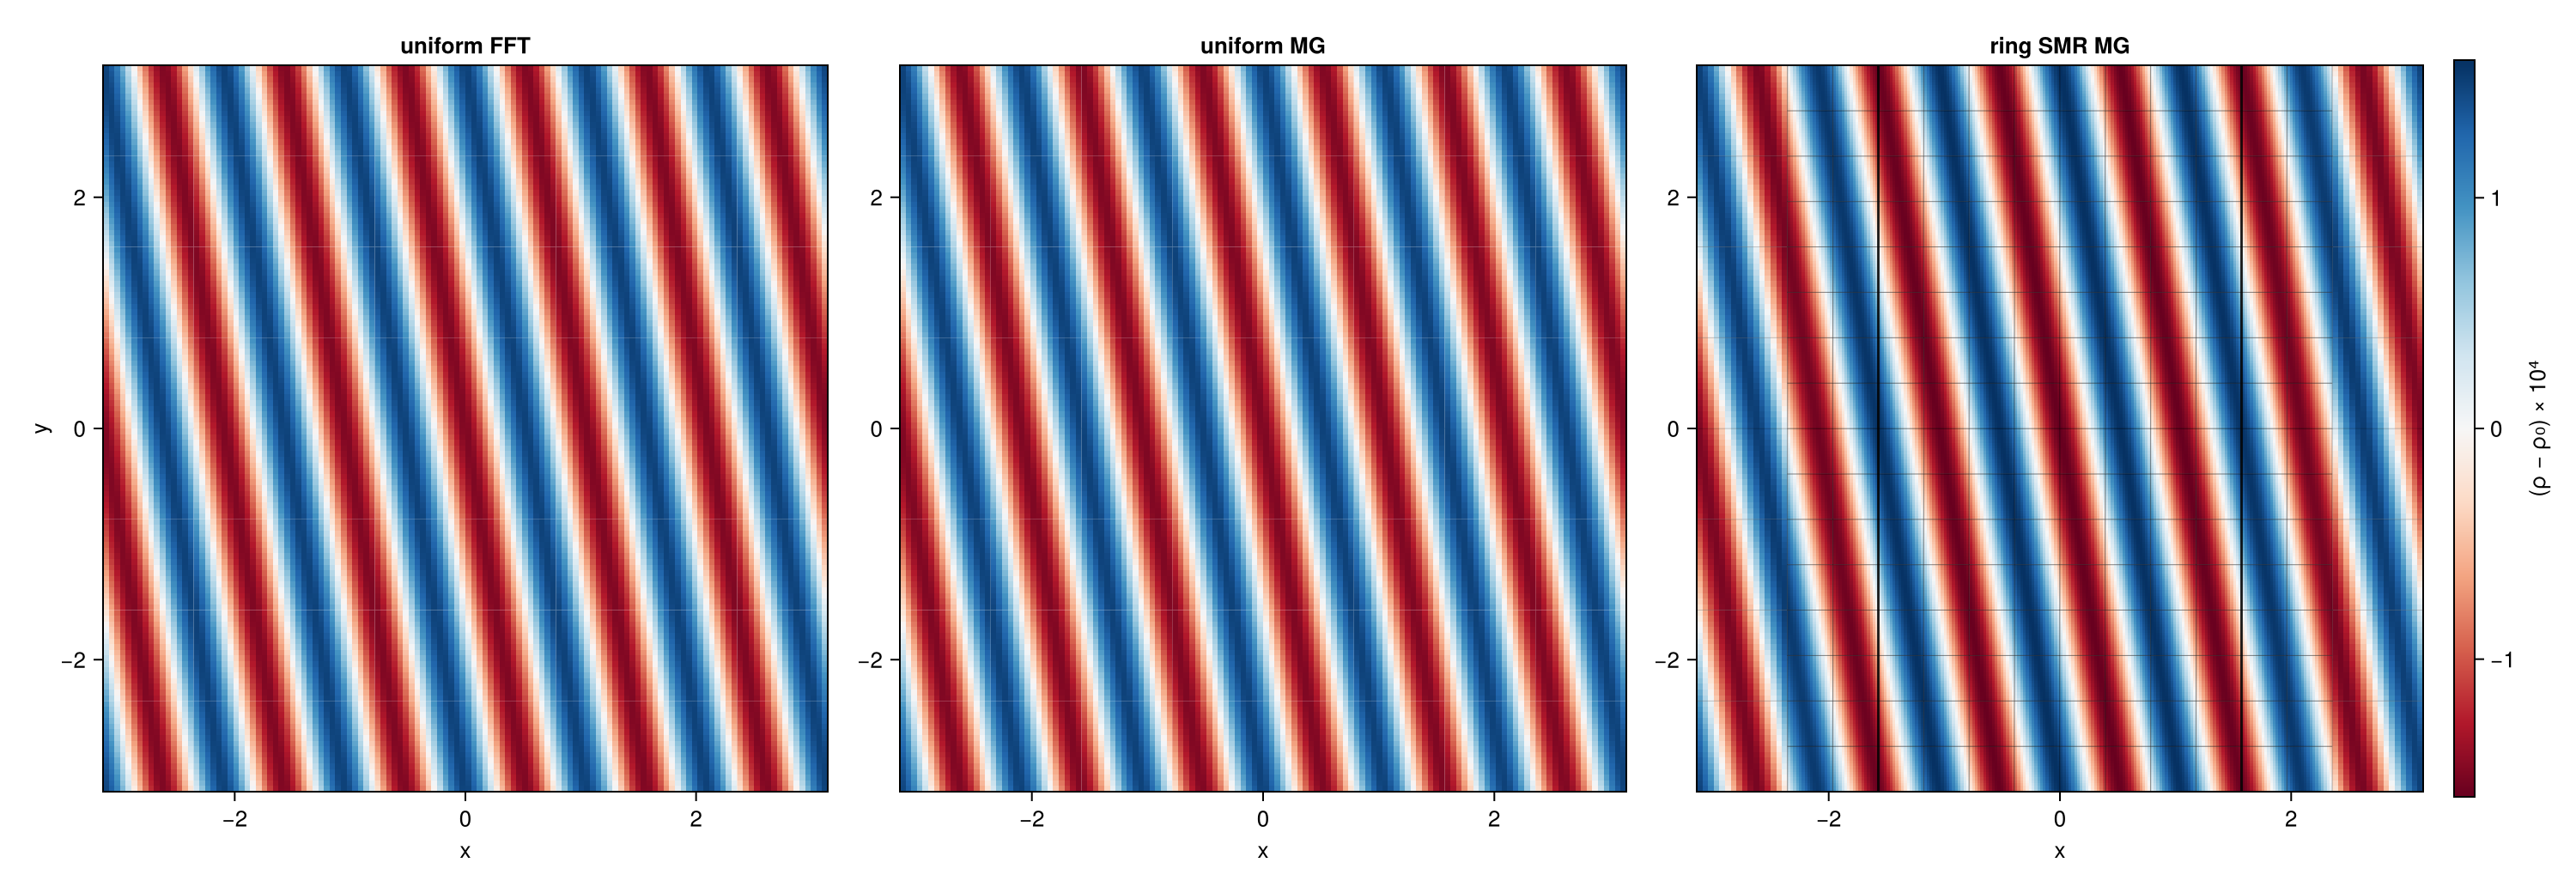

In [83]:
# Final (t = 8 = 2 t_swing) density deviation at the z mid-plane, all three runs.
lastwbin(bn) = joinpath(RUN, "bin", sort(filter(f -> startswith(f, bn * ".hydro_w"),
                                               readdir(joinpath(RUN, "bin"))))[end])
function slices0(bn)
    fb = read_bin_blocks(lastwbin(bn))
    iv = findfirst(==("dens"), fb.vars)
    out = Tuple{NTuple{4,Float64},Int,Matrix{Float64}}[]
    for b in fb.blocks
        n1 = size(b.data, 1)
        h = (b.geom[2] - b.geom[1]) / n1
        (b.geom[5] <= 0 < b.geom[6]) || continue      # one z-layer per (x,y) footprint
        k = clamp(floor(Int, -b.geom[5] / h) + 1, 1, size(b.data, 3))
        push!(out, ((b.geom[1], b.geom[2], b.geom[3], b.geom[4]), b.logical[4],
                    (b.data[:, :, k, iv] .- 1.0) .* 1e4))
    end
    out
end
panels = [("uniform FFT", slices0("sw2a_unif_fft")),
          ("uniform MG", slices0("sw2a_unif_mg")),
          ("ring SMR MG", slices0("sw2a_smr"))]
cr = maximum(maximum(abs, m) for (_, ss) in panels for (_, _, m) in ss)
hms = Any[]
fig = Figure(size=(1500, 520))
for (p, (nm, ss)) in enumerate(panels)
    ax = Axis(fig[1, p]; xlabel="x", ylabel=p == 1 ? "y" : "", title=nm,
              aspect=DataAspect())
    for ((x0, x1, y0, y1), lev, m) in ss
        n1, n2 = size(m)
        xs = range(x0 + (x1-x0)/2n1, x1 - (x1-x0)/2n1, length=n1)
        ys = range(y0 + (y1-y0)/2n2, y1 - (y1-y0)/2n2, length=n2)
        push!(hms, heatmap!(ax, xs, ys, m; colorrange=(-cr, cr), colormap=:RdBu))
        p == 3 && lines!(ax, [x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0];
                         color=(:black, lev > 0 ? 0.35 : 0.15), linewidth=0.5)
    end
    p == 3 && vlines!(ax, [-π/2, π/2]; color=(:black, 0.8), linewidth=1.5)
end
Colorbar(fig[1, 4], hms[1]; label="(ρ − ρ₀) × 10⁴")
dmax = maximum(maximum(abs.(a[3] .- b[3])) for (a, b) in
               zip(slices0("sw2a_unif_fft"), slices0("sw2a_unif_mg")))
@printf("max |FFT − MG| on the uniform slice: %.1e in ρ (float32 quantization scale)\n",
        dmax * 1e-4)
fig


In [ ]:
# ~2 min at first run; SKIPPED unless build-mpi/ and mpirun exist. The SMR shear
# solve across rank counts: printed doubles must agree to all digits (snapshots may
# differ by one float32 ulp from iteration-count noise in the stagnation exit).
if !isfile(MPIBIN) || MPIRUN === nothing
    println("skipped: needs build-mpi/ (-D Athena_ENABLE_MPI=ON) and mpirun on PATH")
else
    run_mpi2a(bn, np; ov=String[]) = begin
        log = joinpath(RUN, "log_" * bn * ".txt")
        isfile(log) || write(log, read(pipeline(Cmd(Cmd(String[
            MPIRUN, "-np", string(np), MPIBIN, "-i",
            joinpath(INPUTS, "tests/mg_poisson_shear_smr.athinput"),
            "job/basename=$bn", ov...]); dir=RUN); stderr=devnull), String))
        read(log, String)
    end
    println("SMR shear shwave error across rank counts (must agree to all digits):")
    for np in (1, 2, 4)
        out = run_mpi2a("p2a_mpi_np$np", np; ov=["problem/profile=shwave"])
        @printf("  np=%d  %s\n", np, grab(out, "SHWAVE ERROR:"))
    end
end


## Playground

| override | effect |
|---|---|
| `shearing_box/orbital_advection=false` | full-velocity (non-FARGO) mode |
| `problem/ipert=1|2|3` | epicycle / vortical shwave / compressive shwave |
| `refined_region1/x1min=…` etc. | move/resize the refined region (policies enforced) |
| `problem/amp=…` | perturbation amplitude (code units, not $c_s$) |
| `time/tlim=…` | run length |

**Next (Phase 1):** `shear_periodic` boundary conditions in the multigrid driver,
validated against the FFT oracle — see `multigrid_selfgravity_validation.pdf` Sec. 5.